## 1. Loading the Dataset

The O*NET Job Titles dataset contains over 54,000 job titles.

The goal is to clean, identify, and classify job titles.

In [2]:
import pandas as pd
import re
#df = pd.read_csv("data/job_titles.csv")
df = pd.read_csv(r"C:\Users\Λάμπρος!\Desktop\greek-job-title-cleaning\job_titles.csv")
df.head()
print(df.shape)
print(df.columns)

,O*NET-SOC Code,Title,Job Title,Short Title,Source(s)
0,11-1011.00,Chief Executives,Aeronautics Commission Director,NaN,08
1,11-1011.00,Chief Executives,Agency Owner,NaN,10
2,11-1011.00,Chief Executives,Agricultural Services Director,NaN,08
3,11-1011.00,Chief Executives,Arts and Humanities Council Director,NaN,08
4,11-1011.00,Chief Executives,Bank President,NaN,09


## 2. Dataset Exploration

Inspection and Pattern Identification

In [5]:
# Select the job title column
job_titles = df["Job Title"]

# Display the first 20 job titles
job_titles.head(20)

0                   Aeronautics Commission Director
1                                      Agency Owner
2                    Agricultural Services Director
3              Arts and Humanities Council Director
4                                    Bank President
5                                      Bureau Chief
6     Business Development Executive (BD Executive)
7         Business Development Officer (BD Officer)
8                       Business Enterprise Officer
9                                Business Executive
10                    CEO (Chief Executive Officer)
11               Chief Administrative Officer (CAO)
12                    Chief Diversity Officer (CDO)
13                    Chief Financial Officer (CFO)
14                  Chief Information Officer (CIO)
15        Chief Information Security Officer (CISO)
16                  Chief Innovation Officer (CINO)
17                      Chief Nursing Officer (CNO)
18                    Chief Operating Officer (COO)
19          

In [6]:
# Check for missing values in the job title column
print("Missing job titles:", job_titles.isna().sum())

Missing job titles: 0


In [7]:
# Display rows where the job title is missing
df[df["Job Title"].isna()]

,O*NET-SOC Code,Title,Job Title,Short Title,Source(s)


In [9]:
# Calculate the character length of each job title
title_length = job_titles.astype(str).str.len()

# Display basic statistics
title_length.describe()

In [10]:
# Display the 10 longest job titles
df.loc[title_length.nlargest(10).index, ["Job Title"]]

,Job Title
54094,"Air Defense Command, Control, Communications, ..."
32497,RVDA Master Certified RV Technician (Recreatio...
6651,HVAC Sensor and Digital Control Designer (Heat...
17568,Nuclear Medicine PET-CT Technologist (Nuclear ...
5003,Applications Software Engineering Information ...
4915,Application Software Engineering IT Specialist...
32673,Residential HVAC Service Technician (Residenti...
33071,Semiconductor Processing Equipment Production ...
4979,Software Engineering Systems IT Specialist (So...
53757,Naval Tactical Data System--Combat Information...


In [11]:
# Find job titles containing at least one digit
titles_with_numbers = df[
    df["Job Title"].str.contains(r"\d", regex=True, na=False)
]

titles_with_numbers[["Job Title"]].head(30)

,Job Title
1157,K-12 Principal (Kindergarten Through Twelfth G...
1158,K-12 School Principal (Kindergarten Through Tw...
1159,K-8 School Principal (Kindergarten Through Eig...
1791,911 Communications Manager
2617,Section 8 Coordinator
2618,Section 8 Housing Specialist
2619,Section 8 Specialist
5195,Three Dimensional Artist (3D Artist)
7489,3D Printing Tech (Three Dimensional Printing T...
8864,K-12 School Psychologist (Kindergarten Through...


In [12]:
# Find titles containing punctuation or special characters
special_titles = df[
    df["Job Title"].str.contains(r"[^A-Za-z0-9\s]", regex=True, na=False)
]

special_titles[["Job Title"]].head(30)

,Job Title
6,Business Development Executive (BD Executive)
7,Business Development Officer (BD Officer)
10,CEO (Chief Executive Officer)
11,Chief Administrative Officer (CAO)
12,Chief Diversity Officer (CDO)
13,Chief Financial Officer (CFO)
14,Chief Information Officer (CIO)
15,Chief Information Security Officer (CISO)
16,Chief Innovation Officer (CINO)
17,Chief Nursing Officer (CNO)


In [13]:
# Search for common seniority terms
seniority_pattern = r"\b(senior|junior|lead|chief|principal|associate)\b"

seniority_titles = df[
    df["Job Title"].str.contains(
        seniority_pattern,
        regex=True,
        case=False,
        na=False
    )
]

seniority_titles[["Job Title"]].head(30)

C:\Users\Λάμπρος!\AppData\Local\Temp\ipykernel_17512\3770080382.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["Job Title"].str.contains(


,Job Title
5,Bureau Chief
10,CEO (Chief Executive Officer)
11,Chief Administrative Officer (CAO)
12,Chief Diversity Officer (CDO)
13,Chief Financial Officer (CFO)
14,Chief Information Officer (CIO)
15,Chief Information Security Officer (CISO)
16,Chief Innovation Officer (CINO)
17,Chief Nursing Officer (CNO)
18,Chief Operating Officer (COO)


In [14]:
# Count job titles containing each seniority term
seniority_terms = [
    "senior",
    "junior",
    "lead",
    "chief",
    "principal",
    "associate"
]

for term in seniority_terms:
    count = df["Job Title"].str.contains(
        rf"\b{term}\b",
        case=False,
        regex=True,
        na=False
    ).sum()
    
    print(f"{term}: {count}")

senior: 16
junior: 4
lead: 24
chief: 102
principal: 15
associate: 392


In [15]:
print("Total job titles:", len(job_titles))
print("Unique job titles:", job_titles.nunique())
print("Missing job titles:", job_titles.isna().sum())

Total job titles: 54269
Unique job titles: 44779
Missing job titles: 0


## 3. Cleaning Job Titles

Job titles can contain inconsistent capitalization, extra spaces,
and unnecessary whitespace.

In [16]:
# Create a copy of the original job titles
df["job_title_clean"] = df["Job Title"].copy()

# Convert job titles to lowercase
df["job_title_clean"] = df["job_title_clean"].str.lower()

# Replace one or more whitespace characters with a single space
df["job_title_clean"] = df["job_title_clean"].str.replace(
    r"\s+",
    " ",
    regex=True
)

# Remove leading and trailing whitespace
df["job_title_clean"] = df["job_title_clean"].str.strip()

# Compare original and cleaned titles
df[["Job Title", "job_title_clean"]].head(20)

,Job Title,job_title_clean
0,Aeronautics Commission Director,aeronautics commission director
1,Agency Owner,agency owner
2,Agricultural Services Director,agricultural services director
3,Arts and Humanities Council Director,arts and humanities council director
4,Bank President,bank president
5,Bureau Chief,bureau chief
6,Business Development Executive (BD Executive),business development executive (bd executive)
7,Business Development Officer (BD Officer),business development officer (bd officer)
8,Business Enterprise Officer,business enterprise officer
9,Business Executive,business executive


In [17]:
# Find titles that start with "senior"
senior_start = df[
    df["job_title_clean"].str.contains(
        r"^senior",
        regex=True,
        na=False
    )
]

senior_start[["Job Title"]].head(20)

,Job Title
10848,Senior Adults Director
53763,Senior Air Director (SAD)
53857,Senior All-Source Intelligence Analysis Officer
53937,Senior Enlisted Damage Control Program Managem...
53938,Senior Naval Parachutist


In [18]:
# Find titles ending with "engineer"
engineer_end = df[
    df["job_title_clean"].str.contains(
        r"engineer$",
        regex=True,
        na=False
    )
]

engineer_end[["Job Title"]].head(20)

,Job Title
381,Facilities Electrical Engineer
382,Facilities Engineer
392,Maintenance Engineer
1651,Power Supply Engineer
2347,Procurement Engineer
2556,Environmental Compliance Engineer
2719,Cost Engineer
2745,Business Intelligence Engineer
2930,Acquisition Logistics Engineer
2934,Cost Engineer


In [19]:
pattern = r"data.scientist"

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(20)

,Job Title
4454,Machine Learning Data Scientist
5398,Security Data Scientist
5659,Machine Learning Data Scientist
5663,Marketing Data Scientist
42313,Biofuels Data Scientist


In [20]:
pattern = r"data.*scientist"

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(30)

,Job Title
4454,Machine Learning Data Scientist
5398,Security Data Scientist
5645,Data Analytic Scientist
5646,Data Analytics Scientist
5652,Data Management Scientist
5659,Machine Learning Data Scientist
5663,Marketing Data Scientist
8406,Ocean Monitoring and Data Assimilation Scientist
42313,Biofuels Data Scientist


In [26]:
# Match "senior" with an optional space before the job title
pattern = r"senior ?engineer"

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(20)

,Job Title


In [27]:
# Match both "vice president" and "vice-president"
pattern = r"vice[- ]?president"

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(20)

,Job Title
35,Executive Vice President (EVP)
36,Finance Vice President (Finance VP)
57,Operations Vice President (Operations VP)
81,CSR and Sustainability VP (Corporate Social Re...
93,Sustainability Initiatives Vice President (Sus...
299,Sales and Marketing VP (Sales and Marketing Vi...
306,Sales VP (Sales Vice President)
353,Institutional Advancement VP (Institutional Ad...
593,Fixed Income Vice President (Fixed Income VP)
597,Investment Analysis Vice President (Investment...


In [28]:
# Find job titles containing exactly two consecutive digits
pattern = r"\d{2}"

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(20)

,Job Title
1157,K-12 Principal (Kindergarten Through Twelfth G...
1158,K-12 School Principal (Kindergarten Through Tw...
1791,911 Communications Manager
8864,K-12 School Psychologist (Kindergarten Through...
13515,K-12 Sub Teacher (Kindergarten to 12th Grade S...
13516,K-12 Substitute Teacher (K-12 Sub Teacher)
17653,EMT-I/85
17654,EMT-I/99
23586,411 Directory Assistance Operator (411 Directo...
25060,911 Dispatcher


In [29]:
# Find one to three consecutive digits
pattern = r"\d{1,3}"

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(20)

,Job Title
1157,K-12 Principal (Kindergarten Through Twelfth G...
1158,K-12 School Principal (Kindergarten Through Tw...
1159,K-8 School Principal (Kindergarten Through Eig...
1791,911 Communications Manager
2617,Section 8 Coordinator
2618,Section 8 Housing Specialist
2619,Section 8 Specialist
5195,Three Dimensional Artist (3D Artist)
7489,3D Printing Tech (Three Dimensional Printing T...
8864,K-12 School Psychologist (Kindergarten Through...


In [30]:
# Find four-letter uppercase abbreviations
pattern = r"\b[A-Z]{4}\b"

matches = df[
    df["Job Title"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(20)

,Job Title
15,Chief Information Security Officer (CISO)
16,Chief Innovation Officer (CINO)
75,Chief Environmental Commitment Officer (CECO)
443,Chief Information Security Officer (CISO)
1169,SPED Admin (Special Education Administrator)
1170,SPED Coordinator (Special Education Coordinator)
1171,SPED Director (Special Education Director)
1172,SPED Superintendent (Special Education Superin...
1332,CFPP (Certified Food Protection Professional)
2194,Licensed Site Remediation Professional (LSRP)


In [32]:
pattern = r"(software|data|machine learning) (engineer|scientist|analyst)"
matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(30)

C:\Users\Λάμπρος!\AppData\Local\Temp\ipykernel_17512\636898899.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["job_title_clean"].str.contains(


,Job Title
489,Software Engineering Director
1275,Data Engineering Director
1276,Data Engineering Manager
2966,Supply Chain Data Analyst
3009,Health Information Management Data Analyst (HI...
4179,Data Analyst
4224,Fraud Data Analyst
4287,Software Analyst
4320,Healthcare Data Analyst
4454,Machine Learning Data Scientist


In [35]:
pattern = (
    r"\b"
    r"(senior|junior|lead|principal)?"
    r"\s*"
    r"(software|data|machine learning)"
    r"\s+"
    r"(engineer|scientist|analyst)"
    r"\b"
)

matches = df[
    df["job_title_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
]

matches[["Job Title"]].head(30)

C:\Users\Λάμπρος!\AppData\Local\Temp\ipykernel_17512\1163775424.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["job_title_clean"].str.contains(


,Job Title
2966,Supply Chain Data Analyst
3009,Health Information Management Data Analyst (HI...
4179,Data Analyst
4224,Fraud Data Analyst
4287,Software Analyst
4320,Healthcare Data Analyst
4454,Machine Learning Data Scientist
4455,Machine Learning Engineer
4457,Machine Learning Scientist
4458,Machine Learning Software Engineer


In [36]:
patterns = {
    "Machine Learning": r"\b(machine learning|deep learning|ml|ai|artificial intelligence)\b",
    
    "Software": r"\b(software|programmer|programming|developer|web developer)\b",
    
    "Data": r"\b(data|database|analytics|analyst|scientist)\b",
    
    "Engineering": r"\b(engineer|engineering)\b",
    
    "HR": r"\b(hr|human resources|recruiter|recruitment)\b",
    
    "Finance": r"\b(finance|financial|accountant|accounting|banking)\b",
    
    "Management": r"\b(manager|management|director|executive)\b"
}
def classify_job_title(title):
    for category, pattern in patterns.items():
        if re.search(pattern, title):
            return category
    
    return "Other"

df["category"] = df["job_title_clean"].apply(classify_job_title)

df[["Job Title", "category"]].head(30)

,Job Title,category
0,Aeronautics Commission Director,Management
1,Agency Owner,Other
2,Agricultural Services Director,Management
3,Arts and Humanities Council Director,Management
4,Bank President,Other
5,Bureau Chief,Other
6,Business Development Executive (BD Executive),Management
7,Business Development Officer (BD Officer),Other
8,Business Enterprise Officer,Other
9,Business Executive,Management


In [37]:
# Select a random sample of 100 job titles
sample = df[["Job Title", "job_title_clean"]].sample(
    n=100,
    random_state=42
).copy()

# Reset the index
sample = sample.reset_index(drop=True)

sample.head(20)

,Job Title,job_title_clean
0,Associate Professor,associate professor
1,Mechanical Design Engineer,mechanical design engineer
2,Investigative Analyst,investigative analyst
3,Garage Manager,garage manager
4,Instrument Technician,instrument technician
5,Statistical Machine Mechanic,statistical machine mechanic
6,Trash Man,trash man
7,Licensing Specialist,licensing specialist
8,Digital Cartographic Technician,digital cartographic technician
9,Turning Sander Operator,turning sander operator


In [40]:
# Create an empty column for manually assigned categories
sample["expected_category"] = ""

In [42]:
# Export the sample for manual labelling
sample.to_csv(
    "evaluation_sample.csv",
    index=False
)

In [43]:
sample=pd.read_csv(r"C:\Users\Λάμπρος!\evaluation_sample.csv")

In [44]:
patterns = {
    "Machine Learning": (
        r"\b("
        r"machine learning|"
        r"deep learning|"
        r"artificial intelligence|"
        r"ai|"
        r"ml"
        r")\b"
    ),

    "Software": (
        r"\b("
        r"software|"
        r"programmer|"
        r"programming|"
        r"developer|"
        r"web developer"
        r")\b"
    ),

    "Data": (
        r"\b("
        r"data|"
        r"database|"
        r"analytics|"
        r"analyst|"
        r"scientist"
        r")\b"
    ),

    "Engineering": (
        r"\b("
        r"engineer|"
        r"engineering"
        r")\b"
    ),

    "HR": (
        r"\b("
        r"hr|"
        r"human resources|"
        r"recruiter|"
        r"recruitment"
        r")\b"
    ),

    "Finance": (
        r"\b("
        r"finance|"
        r"financial|"
        r"accountant|"
        r"accounting|"
        r"banking"
        r")\b"
    ),

    "Management": (
        r"\b("
        r"manager|"
        r"management|"
        r"director|"
        r"executive"
        r")\b"
    )
}

In [45]:
# Apply the regex classifier to the manually labelled sample
sample["predicted_category"] = sample["job_title_clean"].apply(
    classify_job_title
)

sample[
    [
        "Job Title",
        "expected_category",
        "predicted_category"
    ]
].head(30)

,Job Title,expected_category,predicted_category
0,Associate Professor,Other,Other
1,Mechanical Design Engineer,Engineering,Engineering
2,Investigative Analyst,Data,Data
3,Garage Manager,Management,Management
4,Instrument Technician,Engineering,Other
5,Statistical Machine Mechanic,Engineering,Other
6,Trash Man,Other,Other
7,Licensing Specialist,Other,Other
8,Digital Cartographic Technician,Data,Other
9,Turning Sander Operator,Other,Other


In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Calculate accuracy
accuracy = accuracy_score(
    sample["expected_category"],
    sample["predicted_category"]
)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 68.00%


In [47]:
print(
    classification_report(
        sample["expected_category"],
        sample["predicted_category"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Data       0.67      0.40      0.50         5
 Engineering       1.00      0.20      0.33        20
     Finance       0.00      0.00      0.00         4
          HR       0.00      0.00      0.00         2
  Management       0.67      0.44      0.53         9
       Other       0.67      1.00      0.80        58
    Software       0.00      0.00      0.00         2

    accuracy                           0.68       100
   macro avg       0.43      0.29      0.31       100
weighted avg       0.68      0.68      0.60       100



In [51]:
mismatched_rows = sample[sample['expected_category'] != sample['predicted_category']]
mismatched_rows

,Job Title,job_title_clean,expected_category,predicted_category
4,Instrument Technician,instrument technician,Engineering,Other
5,Statistical Machine Mechanic,statistical machine mechanic,Engineering,Other
8,Digital Cartographic Technician,digital cartographic technician,Data,Other
11,Accessibility and Private Residence Lift Techn...,accessibility and private residence lift techn...,Engineering,Other
14,Butt Welder,butt welder,Engineering,Other
21,Network Desktop Support Specialist,network desktop support specialist,Software,Other
24,Loan Adviser,loan adviser,Finance,Other
26,Account Clerk Typist,account clerk typist,Finance,Other
28,Online Producer,online producer,Software,Other
33,Electronic Components Assembler,electronic components assembler,Engineering,Other


In [52]:
patterns = {
    "Machine Learning": (
        r"\b("
        r"machine learning|"
        r"deep learning|"
        r"artificial intelligence|"
        r"ai|"
        r"ml"
        r")\b"
    ),

    "Finance": (
        r"\b("
        r"finance|"
        r"financial|"
        r"accountant|"
        r"accounting|"
        r"banking|"
        r"loan|"
        r"credit|"
        r"investment|"
        r"auditor|"
        r"lease.*analyst"
        r")\b"
    ),

    "HR": (
        r"\b("
        r"hr|"
        r"human resources|"
        r"recruiter|"
        r"recruitment|"
        r"talent|"
        r"staffing|"
        r"personnel"
        r")\b"
    ),

    "Software": (
        r"\b("
        r"software|"
        r"programmer|"
        r"programming|"
        r"developer|"
        r"web developer|"
        r"network|"
        r"desktop support"
        r")\b"
    ),

    "Data": (
        r"\b("
        r"data|"
        r"database|"
        r"analytics|"
        r"scientist|"
        r"statistical|"
        r"survey|"
        r"poll"
        r")\b"
    ),

    "Engineering": (
        r"\b("
        r"engineer|"
        r"engineering|"
        r"technician|"
        r"welder|"
        r"installer|"
        r"mechanic|"
        r"operator|"
        r"inspector|"
        r"assembler|"
        r"builder"
        r")\b"
    ),

    "Management": (
        r"\b("
        r"manager|"
        r"management|"
        r"director|"
        r"executive|"
        r"supervisor|"
        r"superintendent|"
        r"coordinator"
        r")\b"
    )
}

In [53]:
def classify_job_title(title):
    for category, pattern in patterns.items():
        if re.search(pattern, title):
            return category
    
    return "Other"

In [54]:
sample["predicted_category"] = sample["job_title_clean"].apply(
    classify_job_title
)

In [55]:
errors = sample[
    sample["expected_category"] != sample["predicted_category"]
]

errors[
    [
        "Job Title",
        "expected_category",
        "predicted_category"
    ]
]

,Job Title,expected_category,predicted_category
2,Investigative Analyst,Data,Other
5,Statistical Machine Mechanic,Engineering,Data
8,Digital Cartographic Technician,Data,Engineering
9,Turning Sander Operator,Other,Engineering
10,Waxing Machine Operator,Other,Engineering
12,Slicing Machine Operator,Other,Engineering
15,Cloth Finishing Range Operator,Other,Engineering
17,Ditto Machine Operator,Other,Engineering
26,Account Clerk Typist,Finance,Other
28,Online Producer,Software,Other


In [56]:
from sklearn.metrics import accuracy_score, classification_report

print(
    "Accuracy:",
    accuracy_score(
        sample["expected_category"],
        sample["predicted_category"]
    )
)

print(
    classification_report(
        sample["expected_category"],
        sample["predicted_category"],
        zero_division=0
    )
)

Accuracy: 0.77
              precision    recall  f1-score   support

        Data       0.50      0.20      0.29         5
 Engineering       0.53      0.90      0.67        20
     Finance       1.00      0.75      0.86         4
          HR       1.00      0.50      0.67         2
  Management       0.90      1.00      0.95         9
       Other       0.90      0.76      0.82        58
    Software       1.00      0.50      0.67         2

    accuracy                           0.77       100
   macro avg       0.83      0.66      0.70       100
weighted avg       0.81      0.77      0.77       100



In [57]:
mismatched_rows = sample[sample['expected_category'] != sample['predicted_category']]
mismatched_rows

,Job Title,job_title_clean,expected_category,predicted_category
2,Investigative Analyst,investigative analyst,Data,Other
5,Statistical Machine Mechanic,statistical machine mechanic,Engineering,Data
8,Digital Cartographic Technician,digital cartographic technician,Data,Engineering
9,Turning Sander Operator,turning sander operator,Other,Engineering
10,Waxing Machine Operator,waxing machine operator,Other,Engineering
12,Slicing Machine Operator,slicing machine operator,Other,Engineering
15,Cloth Finishing Range Operator,cloth finishing range operator,Other,Engineering
17,Ditto Machine Operator,ditto machine operator,Other,Engineering
26,Account Clerk Typist,account clerk typist,Finance,Other
28,Online Producer,online producer,Software,Other


## 5. Limitations of Regex-Based Classification

The regex classifier successfully identifies job titles containing
explicit keywords and patterns. However, the results demonstrate
that keyword-based classification has important limitations.

Some job titles contain terms associated with multiple categories.
For example, "analyst", "technician", "operator", and "director"
can occur across different occupational fields.

Increasing the number of regex rules can improve performance on the
evaluation sample but may also make the classifier overly specific
to that sample. Therefore, additional rule-based tuning was avoided
to reduce the risk of overfitting.

A more advanced classification system could use machine learning or
natural language processing to incorporate the broader context of
each job title.

## 6. Classification Performance

The regex classifier is evaluated using accuracy, precision, recall,
and F1-score. A confusion matrix is also used to identify which
categories are most frequently confused.

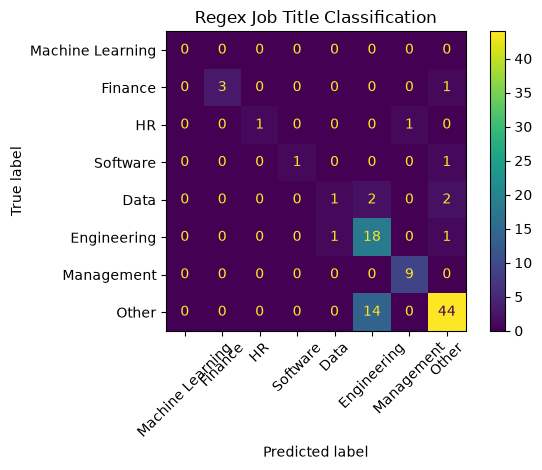

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(
    sample["expected_category"],
    sample["predicted_category"],
    labels=list(patterns.keys()) + ["Other"]
)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(patterns.keys()) + ["Other"]
)

disp.plot(
    xticks_rotation=45
)

plt.title("Regex Job Title Classification")
plt.tight_layout()
plt.show()

In [62]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate precision, recall and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(
    sample["expected_category"],
    sample["predicted_category"],
    average="weighted",
    zero_division=0
)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results["Score"] = results["Score"].round(3)

results

,Metric,Score
0,Accuracy,0.680
1,Weighted Precision,0.813
2,Weighted Recall,0.770
3,Weighted F1,0.771


## 7. Regex Pattern Demonstrations

The following examples demonstrate the main regular expression
features used throughout the project.

| Pattern | Meaning | Example |
|---|---|---|
| `^senior` | Starts with "senior" | Senior Engineer |
| `engineer$` | Ends with "engineer" | Software Engineer |
| `.` | Any single character | Data-Scientist |
| `.*` | Any character, zero or more times | Data Science Scientist |
| `?` | Optional character/group | Vice-President / Vice President |
| `{1,3}` | 1 to 3 repetitions | 123 |
| `(A\|B)` | A or B | Engineer or Scientist |
| `\b` | Word boundary | `\bdata\b` |
| `\d` | Digit | 1, 25, 300 |
| `\s` | Whitespace | Space, tab |

## 8. Conclusion

This project demonstrated how regular expressions can be used to
clean, search, and classify real-world job titles.

The O*NET dataset provided more than 54,000 job-title records,
allowing regex patterns to be tested on a substantially larger
dataset than a manually constructed example.

The analysis demonstrated several regex concepts, including anchors
(`^` and `$`), wildcards (`.`), repetition (`*` and `{}`), optional
patterns (`?`), grouping (`()`), alternatives (`|`), word boundaries
(`\b`), digits (`\d`), and whitespace (`\s`).

The classification experiment also demonstrated an important
limitation of rule-based approaches. Job titles can be ambiguous,
and the same keyword may occur in multiple occupational contexts.
Adding increasingly specific rules can improve performance on a
particular sample while reducing generalizability.

Therefore, regex is useful for text cleaning, pattern detection,
and rule-based preprocessing, but more advanced job-title
classification would benefit from natural language processing or
machine-learning approaches.